# XGBoost Return Forecasting — All 3 Models

Trains and evaluates three XGBoost models that forecast each coin's **7-day-ahead price** on the test set. Each model is trained independently per coin (8 coins total). Forecasts are evaluated at each 7-day rebalance step and outputs are consumed by CMVO for portfolio optimisation.

---

## Models

### Model 1 — XGBoost Base
- **Features:** 14 lagged close prices
- **Target:** Close price 7 days ahead (direct price prediction)
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (`n_estimators=300`, `max_depth=6`, `lr=0.05`)
- **Output:** `xgboost_forecasts.csv`, RMSE1_normalized.csv`

### Model 2 — XGBoost Features
- **Features:** 14 lagged log returns + 30/60-day rolling volatility (lagged)
- **Target:** Log return 7 days ahead â†’ converted back to price
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (same as Base)
- **Output:** `xgb_feature_forecasts.csv`, `xgb_feature_rmses.csv`

### Model 3 — XGBoost Bayesian Optimised (BO)
- **Features:** 14 lagged close prices + 7-day rolling volatility
- **Target:** Close price 7 days ahead
- **Split:** 60/20/20 train/val/test
- **Hyperparameters:** Tuned with Optuna (30 trials, minimising val RMSE)
- **Output:** `xgboost_forecasts_BO_price_vol.csv`, `xgboost_rmse_summary_BO_price_vol.csv`

---

**Note:** Output CSVs are saved to the notebook's working directory. Tiny-price coins (median < 0.01) are log-transformed before training and inverse-transformed for evaluation.

In [1]:
import os
print(os.listdir("klines csv data/prices_cleaned"))

['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


## Model 1 — XGBoost Base


Training: ADAUSDT
ADAUSDT RMSE: 0.160889
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.3043%


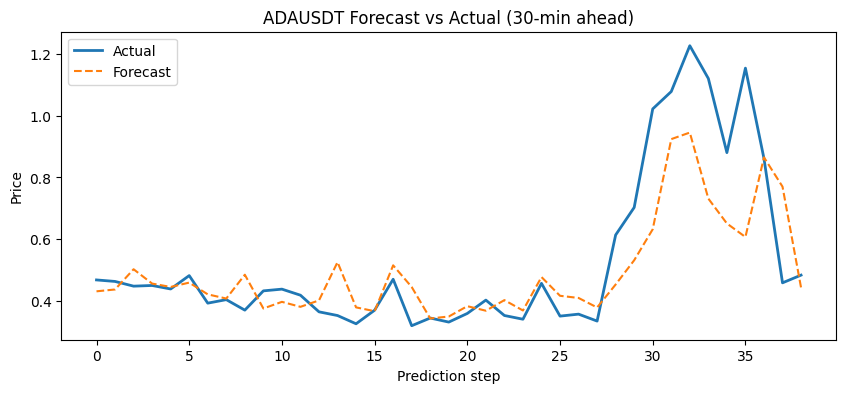


Training: BCHUSDT
BCHUSDT RMSE: 88.484263
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2405%


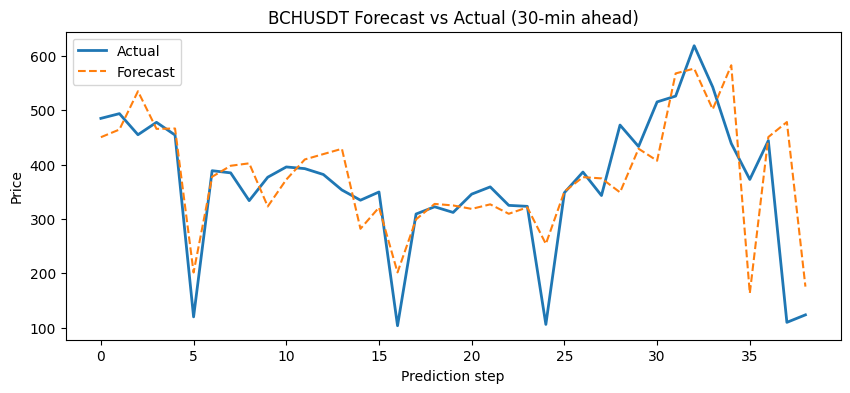


Training: BNBUSDT
BNBUSDT RMSE: 91.077701
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1669%


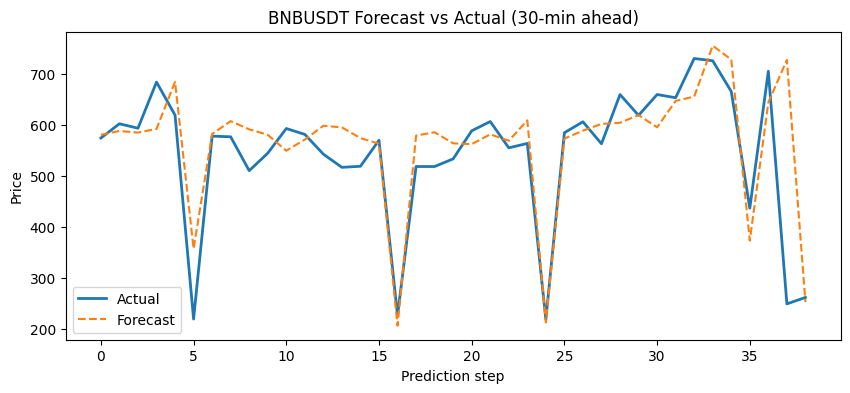


Training: BTCUSDT
BTCUSDT RMSE: 14863.288045
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2312%


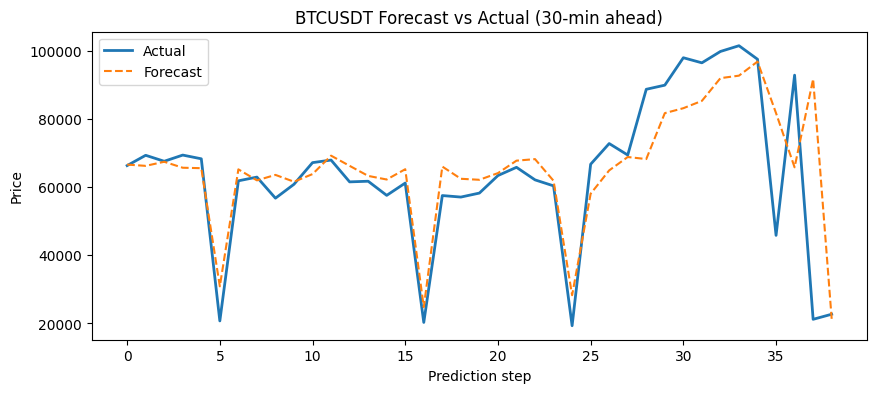


Training: ETHUSDT
ETHUSDT RMSE: 543.011128
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.1904%


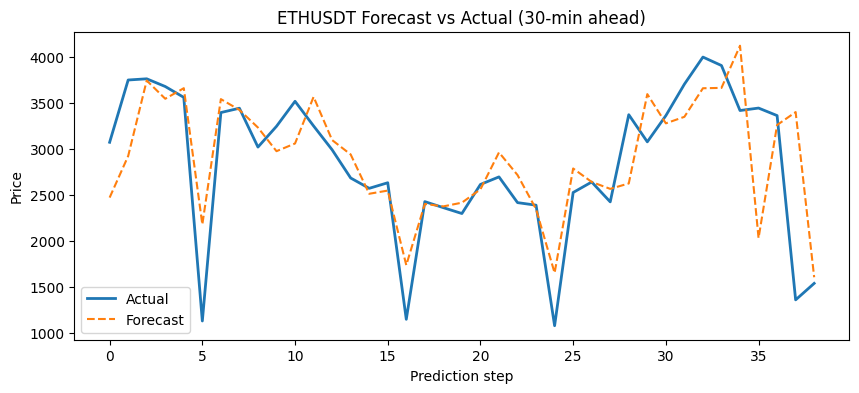


Training: SOLUSDT
SOLUSDT RMSE: 32.606461
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2131%


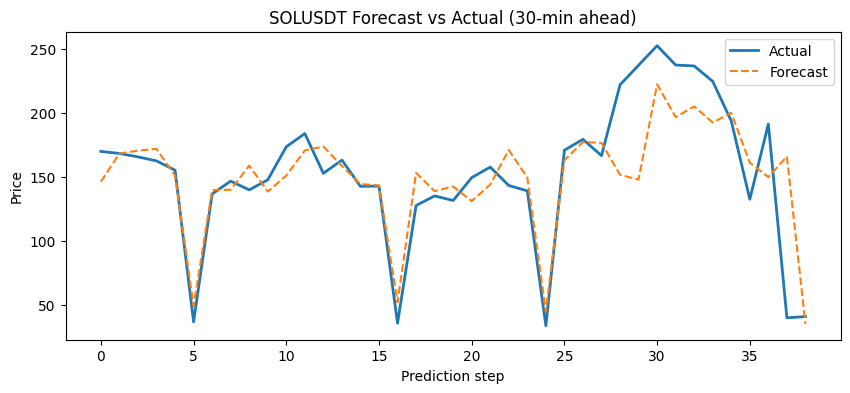


Training: TRXUSDT
TRXUSDT RMSE: 0.056930
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3850%


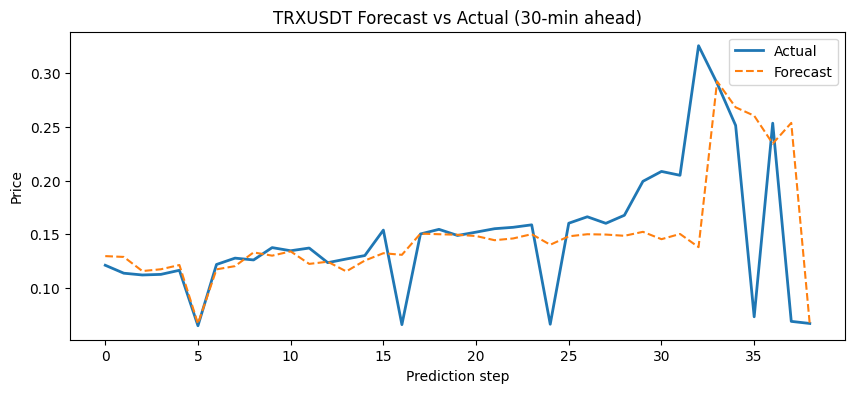


Training: XRPUSDT
XRPUSDT RMSE: 0.490586
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6331%


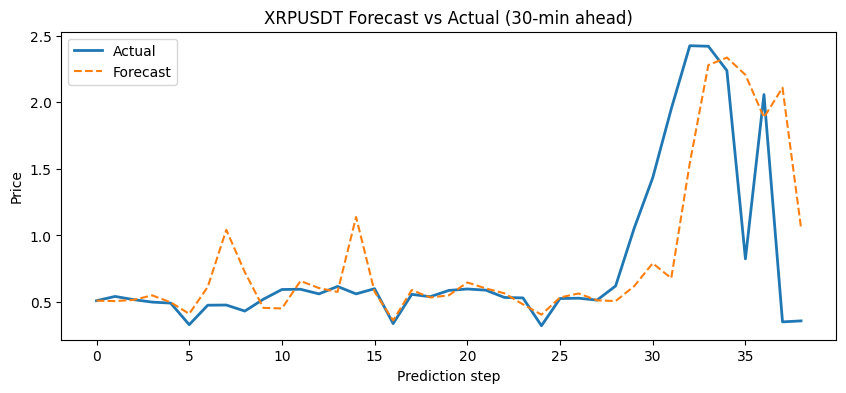

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4672,0.430223,-0.079147
1,ADAUSDT,0.4623,0.436188,-0.056482
2,ADAUSDT,0.4470,0.501902,0.122824
3,ADAUSDT,0.4492,0.455375,0.013747
4,ADAUSDT,0.4378,0.444392,0.015058
...,...,...,...,...
307,XRPUSDT,2.2390,2.336861,0.043707
308,XRPUSDT,0.8240,2.206910,1.678289
309,XRPUSDT,2.0587,1.886836,-0.083482
310,XRPUSDT,0.3505,2.110292,5.020804



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,91.077701,545.711282,0.166897,0.166897
ETHUSDT,543.011128,2851.582564,0.190424,0.190424
SOLUSDT,32.606461,152.974615,0.213149,0.213149
BTCUSDT,14863.288045,64286.045128,0.231206,0.231206
BCHUSDT,88.484263,367.982051,0.240458,0.240458
ADAUSDT,0.160889,0.528646,0.304341,0.304341
TRXUSDT,0.056930,0.147867,0.385008,0.385008
XRPUSDT,0.490586,0.774849,0.633138,0.633138


In [2]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#lags to be 2xhorizon, so 2x30 because 30 minutes
data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

#table of lags
def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

#total files
files = os.listdir(data_folder)

#looping through coins
for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    # ensure numeric just in case
    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    # ensuring chronological order, just in case
    df = df.sort_values("time")

    df = df[["close"]]


    # Handle tiny-price coins

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected â†’ using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    #train test split
    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    #predict
    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    preds = np.array(preds)
    actual = np.array(actual)

    # raw RMSE
    rmse = np.sqrt(mean_squared_error(actual, preds))

    # NEW: normalize by mean actual price
    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    # Ssave table
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - actual) / actual
    })

    all_tables.append(table)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (30-min ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

#final table
final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

# save predictions
final_table.to_csv("12 XGB results/xgboost_forecasts.csv", index=False)

#rmse summary
rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("12 XGB results/RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)

In [3]:
np.save("Results New/XGBoost Base Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/RMSE1_normalized.npy", rmse_table.values)
print("Saved .npy files for Model 1 (Base)")

Saved .npy files for Model 1 (Base)


## Model 2 — XGBoost Features

c:\Users\ameli\Documents\all ur code projects\optimising-dynamic-crypto-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files detected: 8
['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']

Training: ADAUSDT
ADAUSDT RMSE: 0.23214559937900137


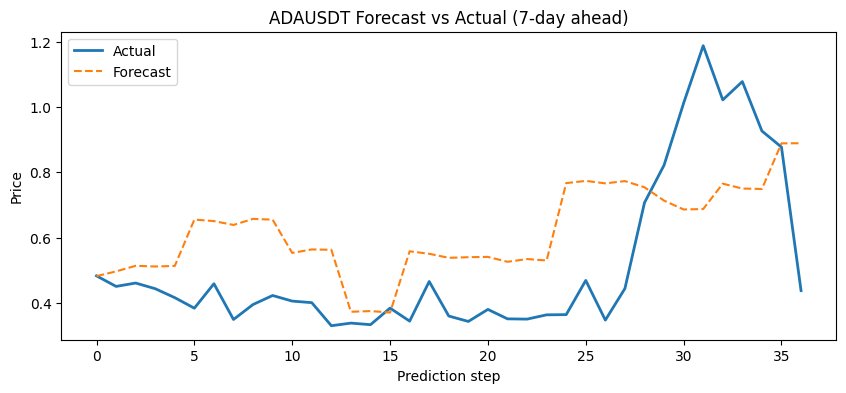


Training: BCHUSDT
BCHUSDT RMSE: 197.0139674373993


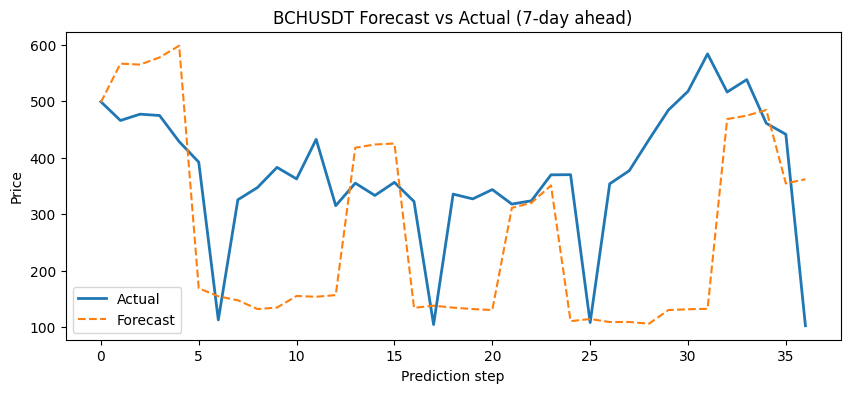


Training: BNBUSDT
BNBUSDT RMSE: 285.7360054027656


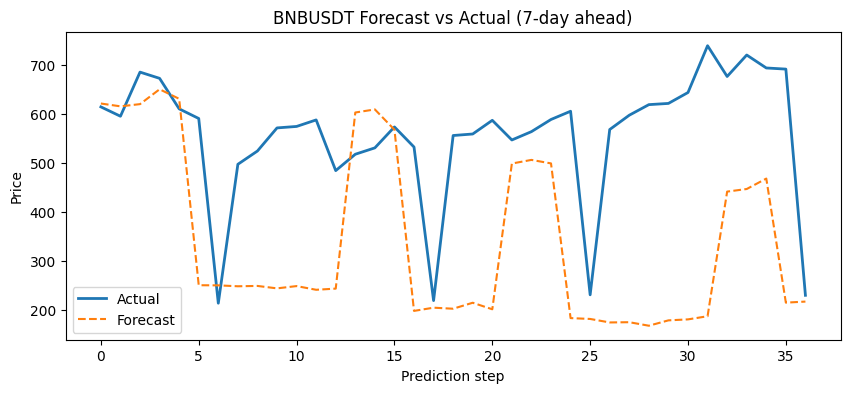


Training: BTCUSDT
BTCUSDT RMSE: 36116.49196802857


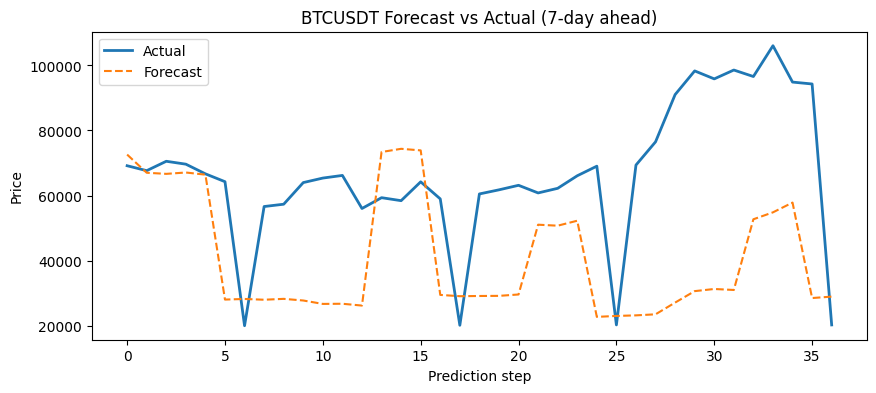


Training: ETHUSDT
ETHUSDT RMSE: 1269.4626584004602


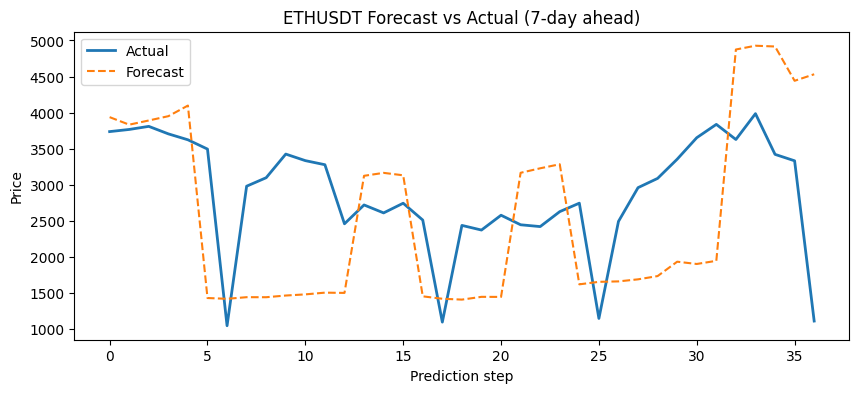


Training: SOLUSDT
SOLUSDT RMSE: 112.78144935719983


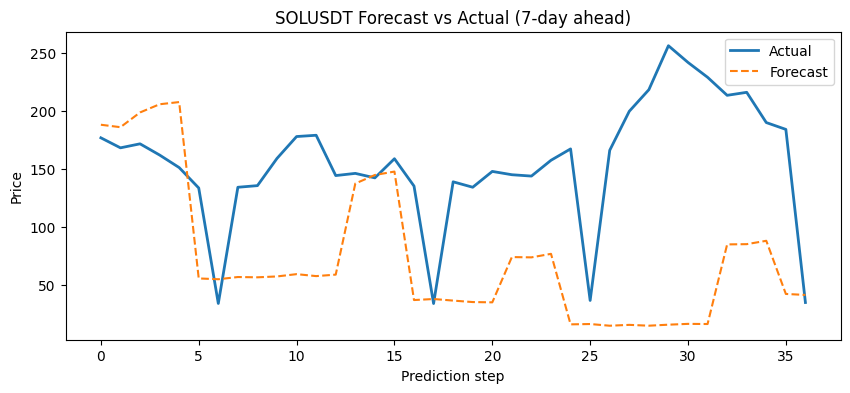


Training: TRXUSDT
TRXUSDT RMSE: 0.09454966702386039


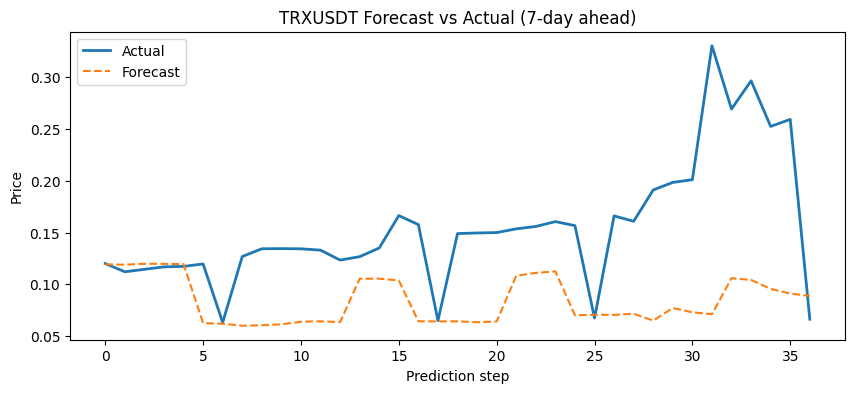


Training: XRPUSDT
XRPUSDT RMSE: 0.600473540026497


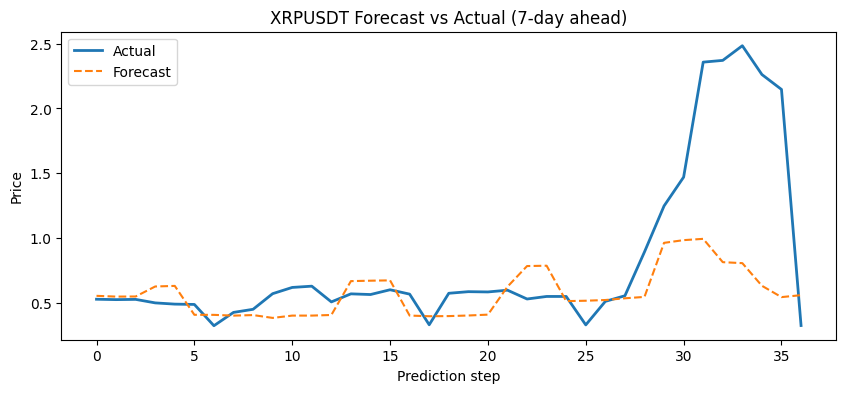

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4835,0.482676,-0.001705
1,ADAUSDT,0.4512,0.497078,0.029401
2,ADAUSDT,0.4615,0.514253,0.033968
3,ADAUSDT,0.4442,0.512066,-0.004262
4,ADAUSDT,0.4168,0.513821,0.003421
...,...,...,...,...
32,XRPUSDT,2.3709,0.812999,-0.200086
33,XRPUSDT,2.4841,0.805393,-0.009400
34,XRPUSDT,2.2617,0.630641,-0.244593
35,XRPUSDT,2.1466,0.543172,-0.149311



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.094550,0.155034,0.609866
ADAUSDT,0.232146,0.516959,0.449060
XRPUSDT,0.600474,0.813641,0.738008
SOLUSDT,112.781449,155.928108,0.723291
BCHUSDT,197.013967,372.651351,0.528682
BNBUSDT,285.736005,558.116486,0.511965
ETHUSDT,1269.462658,2895.692973,0.438397
BTCUSDT,36116.491968,66489.435946,0.543191


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

# Lag funct
def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    # Returns
    df["return"] = np.log(df["close"] / df["close"].shift(1))


    # rolling vol
    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    # Model
    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)



    table = pd.DataFrame({

        "coin": coin,
        "actual": actual_price,
        "forecast": preds_price,
        "returns_predicted": preds_return

    })

    all_tables.append(table)



    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("12 XGB results/xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("12 XGB results/xgb_feature_rmses.csv", index=True)

In [5]:
np.save("Results New/XGBoost Features Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/xgb_feature_rmses.npy", rmse_table.values)
print("Saved .npy files for Model 2 (Features)")

Saved .npy files for Model 2 (Features)


## Model 3 — XGBoost Bayesian Optimised (BO)


Training: ADAUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:23:54,035] A new study created in memory with name: no-name-0e90af12-b83c-47ab-bdc5-8539693c7436


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.341842:   3%|▎         | 1/30 [00:00<00:03,  7.98it/s]

[I 2026-04-19 18:23:54,158] Trial 0 finished with value: 0.34184192324867335 and parameters: {'n_estimators': 201, 'max_depth': 5, 'learning_rate': 0.17656632669864156, 'subsample': 0.5998981584326768, 'colsample_bytree': 0.6057851084920869, 'gamma': 3.311879166724535, 'reg_alpha': 3.9008058671832457, 'reg_lambda': 1.9822160651678349}. Best is trial 0 with value: 0.34184192324867335.


...

[I 2026-04-19 18:24:00,457] Trial 25 finished with value: 0.28074761705897366 and parameters: {'n_estimators': 465, 'max_depth': 4, 'learning_rate': 0.16640430849079774, 'subsample': 0.7108484766292172, 'colsample_bytree': 0.8965360249505545, 'gamma': 1.640923325697954, 'reg_alpha': 1.0228401615068616, 'reg_lambda': 0.400372457748412}. Best is trial 11 with value: 0.17617430516080645.


Best trial: 11. Best value: 0.176174:  93%|█████████▎| 28/30 [00:06<00:00,  4.31it/s]

[I 2026-04-19 18:24:00,696] Trial 26 finished with value: 0.2734461778911974 and parameters: {'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.09624158967164712, 'subsample': 0.7649061891547588, 'colsample_bytree': 0.9643412803564074, 'gamma': 0.9439580800196519, 'reg_alpha': 1.6884405405611258, 'reg_lambda': 0.9188374352151959}. Best is trial 11 with value: 0.17617430516080645.
[I 2026-04-19 18:24:00,890] Trial 27 finished with value: 0.25585023724196626 and parameters: {'n_estimators': 344, 'max_depth': 3, 'learning_rate': 0.12021895967982306, 'subsample': 0.6592876250940785, 'colsample_bytree': 0.8369357219040201, 'gamma': 0.43063478096650126, 'reg_alpha': 2.199422787066738, 'reg_lambda': 2.5700140505517997}. Best is trial 11 with value: 0.17617430516080645.


Best trial: 11. Best value: 0.176174: 100%|██████████| 30/30 [00:07<00:00,  4.13it/s]


[I 2026-04-19 18:24:01,144] Trial 28 finished with value: 0.18149140449458911 and parameters: {'n_estimators': 469, 'max_depth': 4, 'learning_rate': 0.06491795944009285, 'subsample': 0.5920998221307933, 'colsample_bytree': 0.9028019487682581, 'gamma': 0.04328277471202839, 'reg_alpha': 0.3718738614924548, 'reg_lambda': 1.514980686398431}. Best is trial 11 with value: 0.17617430516080645.
[I 2026-04-19 18:24:01,294] Trial 29 finished with value: 0.35288262700576106 and parameters: {'n_estimators': 247, 'max_depth': 5, 'learning_rate': 0.05688449344948839, 'subsample': 0.5972787599637377, 'colsample_bytree': 0.7808022391284257, 'gamma': 4.8997291670922865, 'reg_alpha': 3.054602527965228, 'reg_lambda': 1.6229918513974853}. Best is trial 11 with value: 0.17617430516080645.
Best params: {'n_estimators': 474, 'max_depth': 3, 'learning_rate': 0.11931896064293804, 'subsample': 0.6875383692195813, 'colsample_bytree': 0.978435890026521, 'gamma': 0.08575870239805443, 'reg_alpha': 0.141184514029728

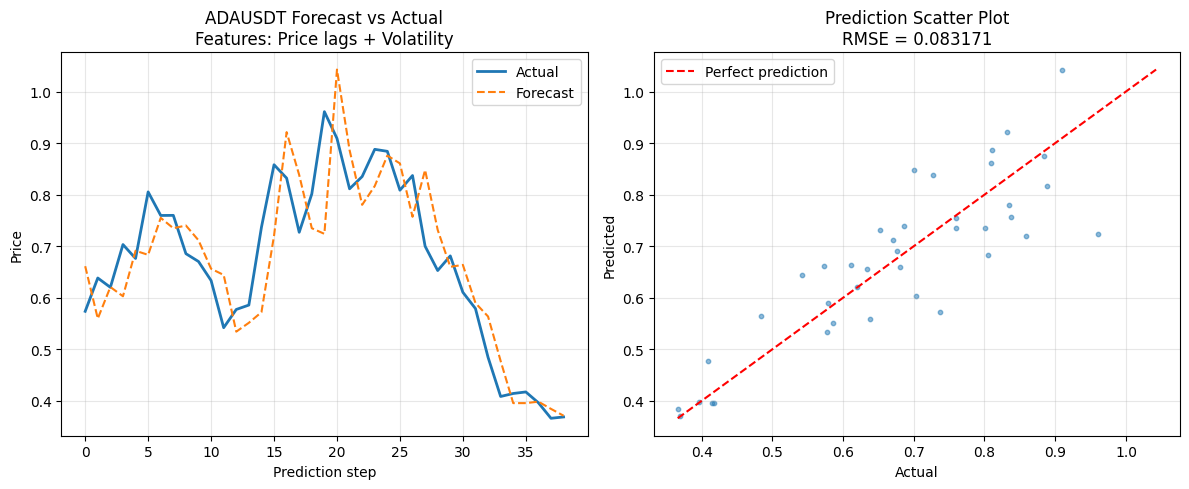

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:24:02,353] A new study created in memory with name: no-name-b02de782-0903-4746-baec-4a09f6b498ae



Training: BCHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 60.5533:   3%|▎         | 1/30 [00:00<00:18,  1.57it/s]

[I 2026-04-19 18:24:02,988] Trial 0 finished with value: 60.553265908942066 and parameters: {'n_estimators': 374, 'max_depth': 6, 'learning_rate': 0.13994335568329794, 'subsample': 0.5201934780239408, 'colsample_bytree': 0.6335206286930142, 'gamma': 4.6690507139525455, 'reg_alpha': 2.5581525020980993, 'reg_lambda': 4.143077759364091}. Best is trial 0 with value: 60.553265908942066.


Best trial: 0. Best value: 60.5533:   7%|▋         | 2/30 [00:01<00:18,  1.51it/s]

...

[I 2026-04-19 18:24:14,160] Trial 26 finished with value: 61.916781046069 and parameters: {'n_estimators': 313, 'max_depth': 4, 'learning_rate': 0.06421286884115729, 'subsample': 0.7890188980676692, 'colsample_bytree': 0.6334817404901291, 'gamma': 2.2037789590589587, 'reg_alpha': 1.087242396913479, 'reg_lambda': 1.4088549109412598}. Best is trial 12 with value: 50.77915500207324.


Best trial: 12. Best value: 50.7792:  97%|█████████▋| 29/30 [00:12<00:00,  2.86it/s]

[I 2026-04-19 18:24:14,655] Trial 27 finished with value: 59.84690298019501 and parameters: {'n_estimators': 349, 'max_depth': 5, 'learning_rate': 0.026464158492462406, 'subsample': 0.7101736669587388, 'colsample_bytree': 0.5041593403913881, 'gamma': 4.424888988772837, 'reg_alpha': 1.833281887746249, 'reg_lambda': 1.1206753087639376}. Best is trial 12 with value: 50.77915500207324.
[I 2026-04-19 18:24:14,842] Trial 28 finished with value: 55.00347672211953 and parameters: {'n_estimators': 190, 'max_depth': 3, 'learning_rate': 0.010096603932617361, 'subsample': 0.6603026213769811, 'colsample_bytree': 0.7482279343497952, 'gamma': 3.5116763678335596, 'reg_alpha': 0.43215240424748713, 'reg_lambda': 1.765441868601501}. Best is trial 12 with value: 50.77915500207324.


Best trial: 12. Best value: 50.7792: 100%|██████████| 30/30 [00:13<00:00,  2.27it/s]


[I 2026-04-19 18:24:15,571] Trial 29 finished with value: 62.655898839797906 and parameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.04517656968492079, 'subsample': 0.7642428995682768, 'colsample_bytree': 0.6402629186222882, 'gamma': 2.9871388801757695, 'reg_alpha': 2.8220827059584512, 'reg_lambda': 2.7723295237409427}. Best is trial 12 with value: 50.77915500207324.
Best params: {'n_estimators': 342, 'max_depth': 3, 'learning_rate': 0.010567901966500495, 'subsample': 0.7987918336947573, 'colsample_bytree': 0.6917260887755842, 'gamma': 0.010954905325682884, 'reg_alpha': 0.13032691176540845, 'reg_lambda': 0.46335079742211593}

Top 10 Most Important Features:
feature  importance
  lag_1    0.244837
  close    0.221481
  lag_2    0.189588
  lag_3    0.108432
  lag_5    0.063794
  lag_4    0.039794
  lag_7    0.021456
 lag_13    0.019922
  lag_8    0.016318
 lag_12    0.013872

BCHUSDT RMSE: 63.932024


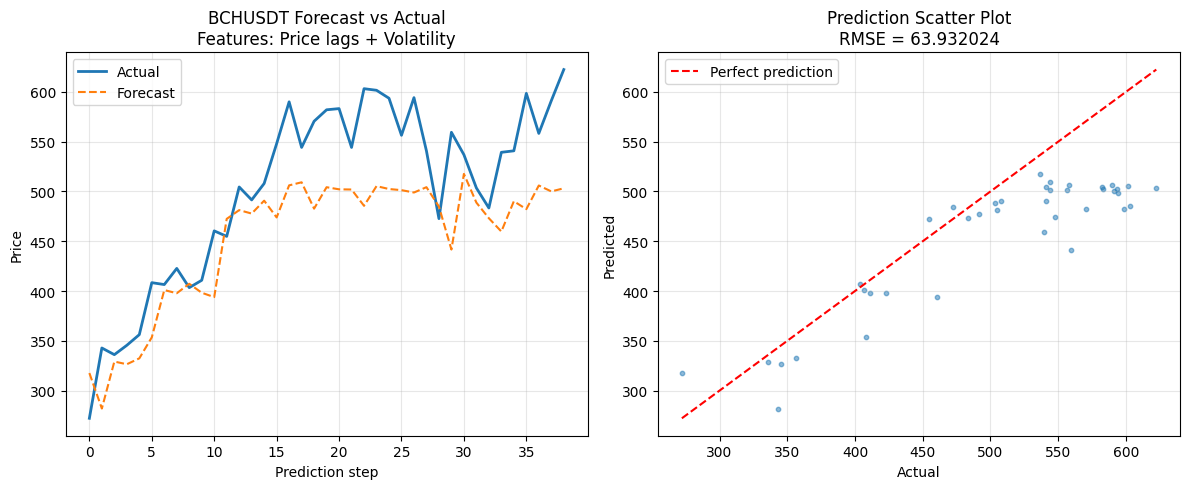

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:24:16,788] A new study created in memory with name: no-name-8c734c76-b50e-4853-826a-424390bdac8a



Training: BNBUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 70.4251:   3%|▎         | 1/30 [00:00<00:13,  2.11it/s]

[I 2026-04-19 18:24:17,261] Trial 0 finished with value: 70.42506765257096 and parameters: {'n_estimators': 436, 'max_depth': 4, 'learning_rate': 0.07428505222372826, 'subsample': 0.6341259367785785, 'colsample_bytree': 0.5878372187608316, 'gamma': 4.2508578291084085, 'reg_alpha': 1.550872019874026, 'reg_lambda': 0.33741505678215045}. Best is trial 0 with value: 70.42506765257096.


Best trial: 0. Best value: 70.4251:   7%|▋         | 2/30 [00:00<00:12,  2.23it/s]

...

[I 2026-04-19 18:24:28,418] Trial 27 finished with value: 71.32671785956362 and parameters: {'n_estimators': 207, 'max_depth': 6, 'learning_rate': 0.12875906730495407, 'subsample': 0.8645509052027178, 'colsample_bytree': 0.895533836179928, 'gamma': 1.1838103452587228, 'reg_alpha': 0.07572788297828763, 'reg_lambda': 4.601706337531009}. Best is trial 21 with value: 68.19607027500963.


Best trial: 21. Best value: 68.1961:  97%|█████████▋| 29/30 [00:11<00:00,  3.25it/s]

[I 2026-04-19 18:24:28,636] Trial 28 finished with value: 69.150179216845 and parameters: {'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.05079690064981514, 'subsample': 0.7879254928607164, 'colsample_bytree': 0.7008916684644222, 'gamma': 1.4804497019105542, 'reg_alpha': 1.3363476317084015, 'reg_lambda': 3.8656191913368128}. Best is trial 21 with value: 68.19607027500963.


Best trial: 21. Best value: 68.1961: 100%|██████████| 30/30 [00:12<00:00,  2.48it/s]


[I 2026-04-19 18:24:28,878] Trial 29 finished with value: 71.05498868518308 and parameters: {'n_estimators': 148, 'max_depth': 4, 'learning_rate': 0.18596916928167778, 'subsample': 0.7306750129234588, 'colsample_bytree': 0.8080197348322851, 'gamma': 0.8597725937834955, 'reg_alpha': 1.8023071887992064, 'reg_lambda': 0.2684268718630882}. Best is trial 21 with value: 68.19607027500963.
Best params: {'n_estimators': 281, 'max_depth': 3, 'learning_rate': 0.18322721523047206, 'subsample': 0.8825651941963703, 'colsample_bytree': 0.7949022372911456, 'gamma': 1.6608412985664038, 'reg_alpha': 1.6543141923713376, 'reg_lambda': 3.593918360859855}

Top 10 Most Important Features:
feature  importance
  lag_1    0.432846
  lag_2    0.260379
  close    0.255432
  lag_6    0.006666
  lag_4    0.005854
 lag_11    0.005175
 lag_13    0.004496
 lag_14    0.004414
  lag_3    0.004272
 lag_12    0.003956

BNBUSDT RMSE: 218.640986


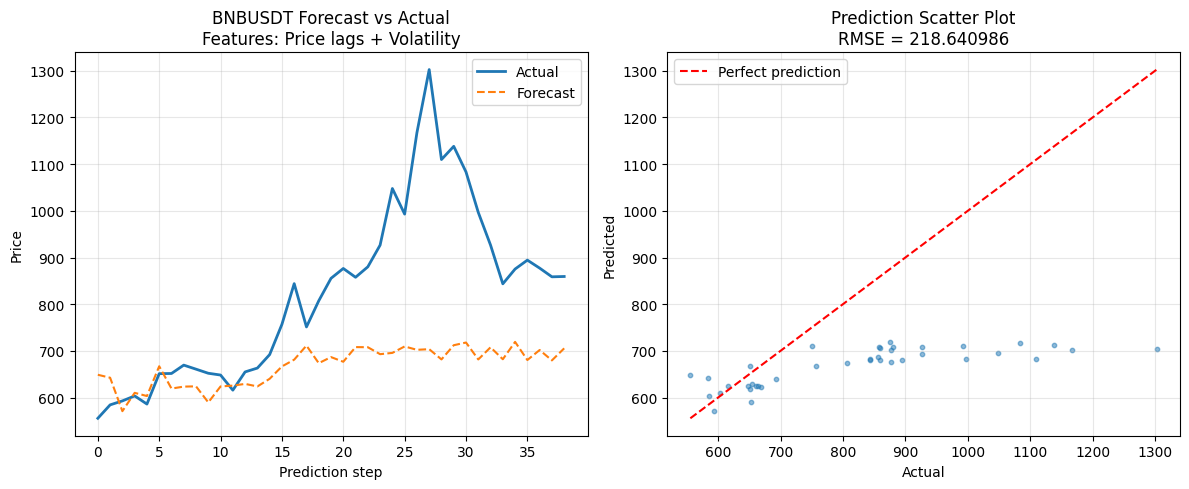

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:24:30,123] A new study created in memory with name: no-name-894e0a28-2f2e-4612-9081-b9b2f939f5b8



Training: BTCUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 23432.7:   3%|▎         | 1/30 [00:00<00:20,  1.43it/s]

[I 2026-04-19 18:24:30,822] Trial 0 finished with value: 23432.683822904564 and parameters: {'n_estimators': 105, 'max_depth': 10, 'learning_rate': 0.19425727330013534, 'subsample': 0.9317710438797037, 'colsample_bytree': 0.6018603630643968, 'gamma': 1.0691800227973274, 'reg_alpha': 4.215955237461719, 'reg_lambda': 4.734439044762189}. Best is trial 0 with value: 23432.683822904564.


Best trial: 0. Best value: 23432.7:   7%|▋         | 2/30 [00:01<00:13,  2.14it/s]

...

[I 2026-04-19 18:24:44,010] Trial 27 finished with value: 21510.65001499796 and parameters: {'n_estimators': 370, 'max_depth': 3, 'learning_rate': 0.030560234783999093, 'subsample': 0.9081182605381126, 'colsample_bytree': 0.5505969426556949, 'gamma': 4.1409087697847315, 'reg_alpha': 1.426350904522061, 'reg_lambda': 0.5017351245672074}. Best is trial 24 with value: 20678.56428314356.


Best trial: 24. Best value: 20678.6:  97%|█████████▋| 29/30 [00:14<00:00,  2.56it/s]

[I 2026-04-19 18:24:44,403] Trial 28 finished with value: 21778.057887467956 and parameters: {'n_estimators': 387, 'max_depth': 4, 'learning_rate': 0.026837000917999215, 'subsample': 0.9080913165239353, 'colsample_bytree': 0.5264211634817931, 'gamma': 4.238061003368615, 'reg_alpha': 2.2270403634278506, 'reg_lambda': 2.4089671699138586}. Best is trial 24 with value: 20678.56428314356.


Best trial: 24. Best value: 20678.6: 100%|██████████| 30/30 [00:15<00:00,  1.94it/s]


[I 2026-04-19 18:24:45,616] Trial 29 finished with value: 24126.152769091153 and parameters: {'n_estimators': 468, 'max_depth': 9, 'learning_rate': 0.09378137171698572, 'subsample': 0.946782117895628, 'colsample_bytree': 0.5745141324961686, 'gamma': 4.082448920053116, 'reg_alpha': 1.8783354849321046, 'reg_lambda': 1.178220259399632}. Best is trial 24 with value: 20678.56428314356.
Best params: {'n_estimators': 302, 'max_depth': 3, 'learning_rate': 0.032974549270913235, 'subsample': 0.9863049272852988, 'colsample_bytree': 0.7048240616675967, 'gamma': 3.249428152709035, 'reg_alpha': 1.4259474401300103, 'reg_lambda': 0.4451711922969145}

Top 10 Most Important Features:
feature  importance
  lag_4    0.336819
  lag_5    0.256661
  lag_1    0.135497
  lag_9    0.086578
  close    0.076469
  lag_8    0.043327
  lag_7    0.033418
  lag_2    0.012753
  lag_3    0.007164
 lag_12    0.002738

BTCUSDT RMSE: 13614.780602


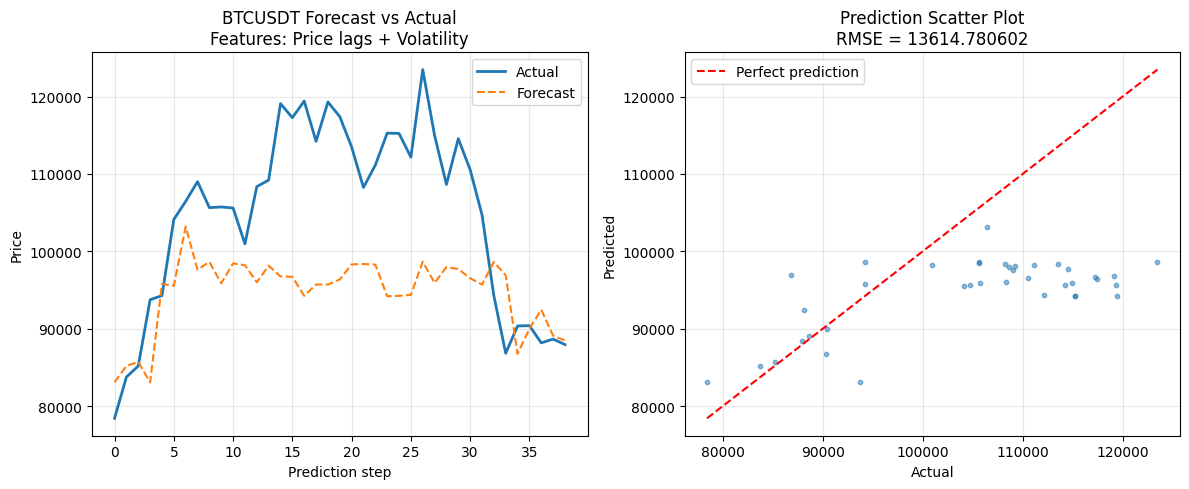

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:24:46,733] A new study created in memory with name: no-name-257bba5b-45a2-4d58-8178-204a59311019



Training: ETHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 320.898:   3%|▎         | 1/30 [00:00<00:10,  2.88it/s]

[I 2026-04-19 18:24:47,077] Trial 0 finished with value: 320.89753578087556 and parameters: {'n_estimators': 389, 'max_depth': 3, 'learning_rate': 0.18590779491142387, 'subsample': 0.8928148051665745, 'colsample_bytree': 0.7476136274798274, 'gamma': 1.070945367270949, 'reg_alpha': 4.571137028904575, 'reg_lambda': 0.8733067417378215}. Best is trial 0 with value: 320.89753578087556.


Best trial: 1. Best value: 313.6:   7%|▋         | 2/30 [00:00<00:09,  2.83it/s]  

...

[I 2026-04-19 18:25:02,603] Trial 27 finished with value: 281.6662561919683 and parameters: {'n_estimators': 365, 'max_depth': 3, 'learning_rate': 0.010322017273339795, 'subsample': 0.6035177039841104, 'colsample_bytree': 0.8026506823490883, 'gamma': 0.0664787197785848, 'reg_alpha': 2.0875416448410813, 'reg_lambda': 3.941903470183961}. Best is trial 27 with value: 281.6662561919683.


Best trial: 28. Best value: 279.464:  97%|█████████▋| 29/30 [00:16<00:00,  2.05it/s]

[I 2026-04-19 18:25:02,991] Trial 28 finished with value: 279.4641317348638 and parameters: {'n_estimators': 365, 'max_depth': 3, 'learning_rate': 0.010228529697816069, 'subsample': 0.819910251142208, 'colsample_bytree': 0.9221583193305257, 'gamma': 0.23429108633628504, 'reg_alpha': 2.1778426178962684, 'reg_lambda': 3.8493947846449927}. Best is trial 28 with value: 279.4641317348638.


Best trial: 28. Best value: 279.464: 100%|██████████| 30/30 [00:16<00:00,  1.79it/s]


[I 2026-04-19 18:25:03,452] Trial 29 finished with value: 282.966872619136 and parameters: {'n_estimators': 368, 'max_depth': 3, 'learning_rate': 0.013822707167197022, 'subsample': 0.8568405206552673, 'colsample_bytree': 0.9513313548350941, 'gamma': 0.5723481110171696, 'reg_alpha': 4.970667679166988, 'reg_lambda': 3.0081462266988277}. Best is trial 28 with value: 279.4641317348638.
Best params: {'n_estimators': 365, 'max_depth': 3, 'learning_rate': 0.010228529697816069, 'subsample': 0.819910251142208, 'colsample_bytree': 0.9221583193305257, 'gamma': 0.23429108633628504, 'reg_alpha': 2.1778426178962684, 'reg_lambda': 3.8493947846449927}

Top 10 Most Important Features:
feature  importance
  lag_2    0.440235
  close    0.213561
  lag_1    0.207182
  lag_3    0.027617
  lag_4    0.023322
  lag_5    0.013908
  lag_6    0.012595
  lag_7    0.010095
 lag_13    0.007246
  lag_8    0.007128

ETHUSDT RMSE: 557.175985


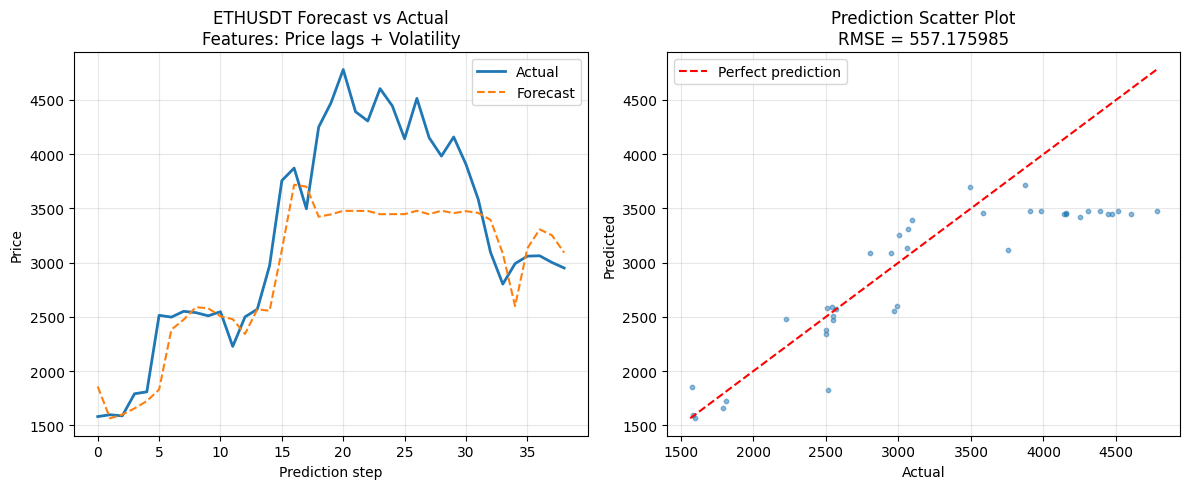

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:25:04,658] A new study created in memory with name: no-name-27826088-d78b-4eeb-b03d-18689db0f9fc



Training: SOLUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 41.965:   3%|▎         | 1/30 [00:00<00:13,  2.09it/s]

[I 2026-04-19 18:25:05,134] Trial 0 finished with value: 41.96500658429137 and parameters: {'n_estimators': 375, 'max_depth': 5, 'learning_rate': 0.016437869461425458, 'subsample': 0.5602290763895661, 'colsample_bytree': 0.699618651955702, 'gamma': 3.0119038531491005, 'reg_alpha': 1.3006640355828685, 'reg_lambda': 4.587191439247887}. Best is trial 0 with value: 41.96500658429137.


Best trial: 1. Best value: 39.6184:   7%|▋         | 2/30 [00:00<00:10,  2.55it/s]

...

[I 2026-04-19 18:25:14,832] Trial 27 finished with value: 42.53054117687654 and parameters: {'n_estimators': 269, 'max_depth': 4, 'learning_rate': 0.05953152180983887, 'subsample': 0.6203252038256153, 'colsample_bytree': 0.8327695563267616, 'gamma': 0.41797097418781065, 'reg_alpha': 2.678232112551432, 'reg_lambda': 4.361081877170795}. Best is trial 15 with value: 34.84967948866264.


Best trial: 15. Best value: 34.8497:  97%|█████████▋| 29/30 [00:10<00:00,  2.59it/s]

[I 2026-04-19 18:25:15,207] Trial 28 finished with value: 39.21856377307273 and parameters: {'n_estimators': 218, 'max_depth': 5, 'learning_rate': 0.08078938939584075, 'subsample': 0.760144939498454, 'colsample_bytree': 0.7235443316775577, 'gamma': 0.7871586161617, 'reg_alpha': 3.437855599017235, 'reg_lambda': 3.8054496027737623}. Best is trial 15 with value: 34.84967948866264.


Best trial: 15. Best value: 34.8497: 100%|██████████| 30/30 [00:11<00:00,  2.72it/s]


[I 2026-04-19 18:25:15,671] Trial 29 finished with value: 41.88548052288133 and parameters: {'n_estimators': 334, 'max_depth': 5, 'learning_rate': 0.06521574211812516, 'subsample': 0.5754610279906642, 'colsample_bytree': 0.6905556393091785, 'gamma': 2.35729427467156, 'reg_alpha': 2.148065639751832, 'reg_lambda': 2.33575106009737}. Best is trial 15 with value: 34.84967948866264.
Best params: {'n_estimators': 207, 'max_depth': 3, 'learning_rate': 0.12201699537322332, 'subsample': 0.705433598655213, 'colsample_bytree': 0.8867477313051088, 'gamma': 0.8592999906751966, 'reg_alpha': 4.486491782543164, 'reg_lambda': 0.03555671751149081}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.306982
     lag_2    0.282998
     close    0.277947
     lag_6    0.056801
     lag_9    0.013410
    lag_11    0.010786
     lag_3    0.010376
volatility    0.005653
    lag_14    0.004948
    lag_12    0.004776

SOLUSDT RMSE: 19.618005


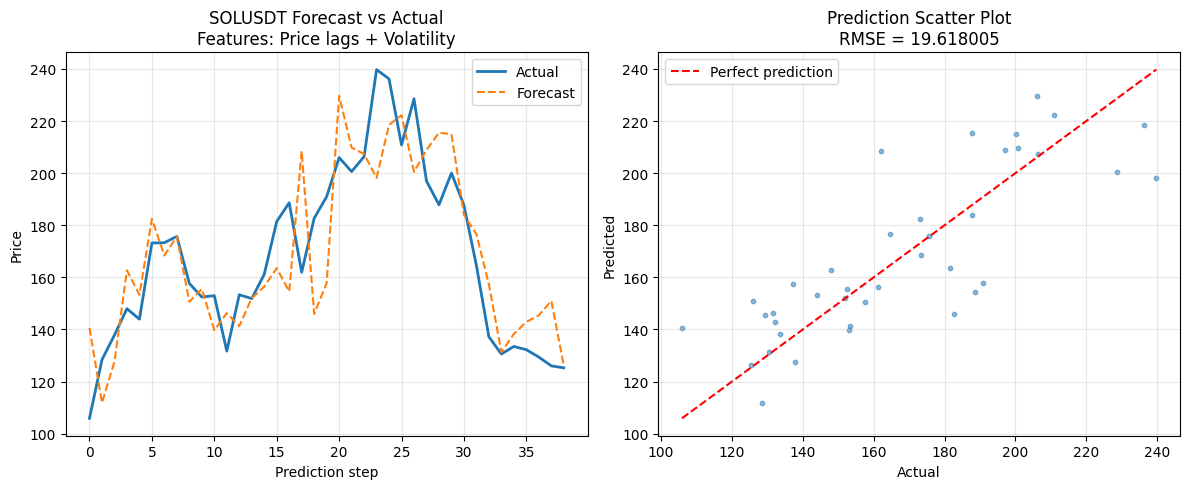

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:25:16,688] A new study created in memory with name: no-name-5f097102-e772-4683-8154-c4d58e90daf0



Training: TRXUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.12603:   7%|▋         | 2/30 [00:00<00:03,  8.20it/s]

[I 2026-04-19 18:25:16,779] Trial 0 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 177, 'max_depth': 8, 'learning_rate': 0.03738497827787637, 'subsample': 0.7054519163394528, 'colsample_bytree': 0.5567632466872221, 'gamma': 1.7254952582000749, 'reg_alpha': 1.612014311955266, 'reg_lambda': 0.4452513603253211}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-19 18:25:16,930] Trial 1 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 224, 'max_depth': 5, 'learning_rate': 0.06993611941802987, 'subsample': 0.6944917053799113, 'colsample_bytree': 0.6895238104118524, 'gamma': 0.5886331100617881, 'reg_alpha': 1.9479584735945248, 'reg_lambda': 3.418597484025494}. Best is trial 0 with value: 0.12602966170678476.


Best trial: 0. Best value: 0.12603:  13%|█▎        | 4/30 [00:00<00:03,  6.82it/s]

...

[I 2026-04-19 18:25:22,233] Trial 26 finished with value: 0.12618193816645493 and parameters: {'n_estimators': 435, 'max_depth': 6, 'learning_rate': 0.14484650953075667, 'subsample': 0.7374079787059035, 'colsample_bytree': 0.838867706250529, 'gamma': 2.0987638814122365, 'reg_alpha': 0.3486542534930518, 'reg_lambda': 0.05609618823406004}. Best is trial 16 with value: 0.12578757137213264.


Best trial: 16. Best value: 0.125788:  97%|█████████▋| 29/30 [00:05<00:00,  4.52it/s]

[I 2026-04-19 18:25:22,445] Trial 27 finished with value: 0.12601533661827696 and parameters: {'n_estimators': 390, 'max_depth': 3, 'learning_rate': 0.12416164497606266, 'subsample': 0.6571543116550445, 'colsample_bytree': 0.7267024001199045, 'gamma': 1.4026430351436328, 'reg_alpha': 0.4081644039429895, 'reg_lambda': 4.565478349466289}. Best is trial 16 with value: 0.12578757137213264.
[I 2026-04-19 18:25:22,638] Trial 28 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 352, 'max_depth': 4, 'learning_rate': 0.08329134495451511, 'subsample': 0.5978350768395266, 'colsample_bytree': 0.8003836049581334, 'gamma': 0.6353059082540304, 'reg_alpha': 1.3473732906339668, 'reg_lambda': 3.8487212793379646}. Best is trial 16 with value: 0.12578757137213264.


Best trial: 16. Best value: 0.125788: 100%|██████████| 30/30 [00:06<00:00,  4.80it/s]


[I 2026-04-19 18:25:22,934] Trial 29 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.17888030631347202, 'subsample': 0.9973534497143367, 'colsample_bytree': 0.9268060995226107, 'gamma': 1.8567916670277667, 'reg_alpha': 1.5284181400310795, 'reg_lambda': 2.9305290204034766}. Best is trial 16 with value: 0.12578757137213264.
Best params: {'n_estimators': 428, 'max_depth': 6, 'learning_rate': 0.16294398962841952, 'subsample': 0.5758329348617134, 'colsample_bytree': 0.8187424679389894, 'gamma': 2.310951530861345, 'reg_alpha': 0.1437123587288605, 'reg_lambda': 1.5733542688148843}

Top 10 Most Important Features:
   feature  importance
     close         0.0
log_return         0.0
volatility         0.0
     lag_1         0.0
     lag_2         0.0
     lag_3         0.0
     lag_4         0.0
     lag_5         0.0
     lag_6         0.0
     lag_7         0.0

TRXUSDT RMSE: 0.187022


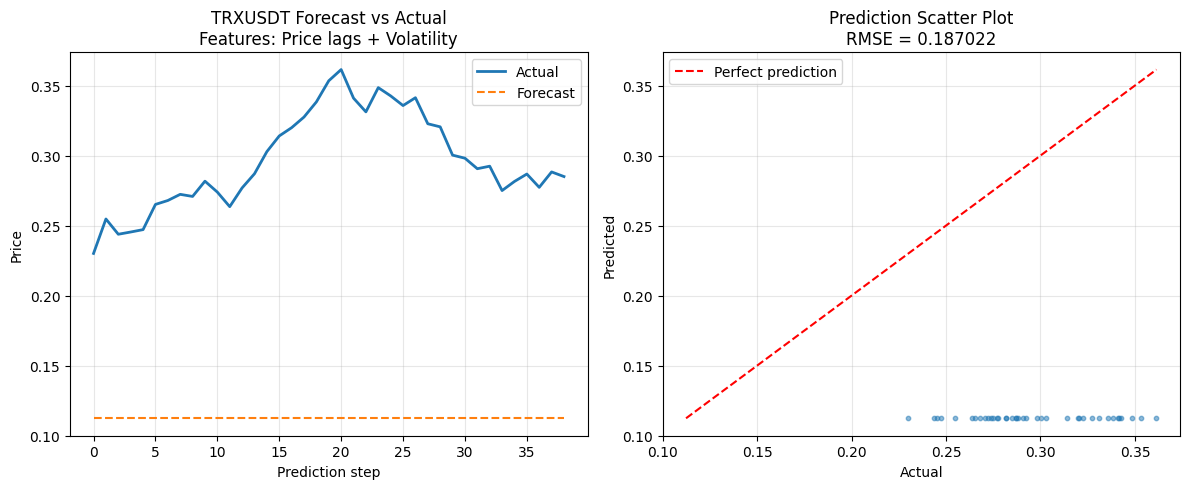

C:\Users\ameli\AppData\Local\Temp\ipykernel_14068\1258970950.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 18:25:23,913] A new study created in memory with name: no-name-55c0bb67-ea0e-4d40-9c28-d40ed07ce5d2



Training: XRPUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 1. Best value: 1.39756:   7%|▋         | 2/30 [00:00<00:04,  5.84it/s]

[I 2026-04-19 18:25:24,113] Trial 0 finished with value: 1.3980582308886842 and parameters: {'n_estimators': 438, 'max_depth': 9, 'learning_rate': 0.06045040890721961, 'subsample': 0.8661293088017974, 'colsample_bytree': 0.8598443760994943, 'gamma': 4.128874200316941, 'reg_alpha': 2.6729280613262887, 'reg_lambda': 4.640829927408333}. Best is trial 0 with value: 1.3980582308886842.
[I 2026-04-19 18:25:24,263] Trial 1 finished with value: 1.3975603065745943 and parameters: {'n_estimators': 293, 'max_depth': 7, 'learning_rate': 0.025017488347273, 'subsample': 0.5197492292753162, 'colsample_bytree': 0.8254189864579724, 'gamma': 4.655629540869455, 'reg_alpha': 0.6211130971434953, 'reg_lambda': 1.8585566380982028}. Best is trial 1 with value: 1.3975603065745943.


Best trial: 2. Best value: 1.36451:  13%|█▎        | 4/30 [00:00<00:03,  6.82it/s]

...

[I 2026-04-19 18:25:28,533] Trial 24 finished with value: 1.3699199247403364 and parameters: {'n_estimators': 329, 'max_depth': 4, 'learning_rate': 0.10392684929653812, 'subsample': 0.7505333864539243, 'colsample_bytree': 0.7647174564495504, 'gamma': 1.534540691680117, 'reg_alpha': 1.5609161449979043, 'reg_lambda': 1.5645898802952005}. Best is trial 16 with value: 1.3004146669296017.
[I 2026-04-19 18:25:28,699] Trial 25 finished with value: 1.3343586714809812 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.08142876952169005, 'subsample': 0.9050188288725961, 'colsample_bytree': 0.6426944932641094, 'gamma': 0.356636400877529, 'reg_alpha': 0.6300896880436002, 'reg_lambda': 3.2648232205844727}. Best is trial 16 with value: 1.3004146669296017.


Best trial: 27. Best value: 1.27784:  93%|█████████▎| 28/30 [00:05<00:00,  5.48it/s]

[I 2026-04-19 18:25:28,901] Trial 26 finished with value: 1.3562345341999207 and parameters: {'n_estimators': 372, 'max_depth': 3, 'learning_rate': 0.04845311545095185, 'subsample': 0.8418902617720089, 'colsample_bytree': 0.9979694927541836, 'gamma': 0.9529946806853575, 'reg_alpha': 1.0667651742286424, 'reg_lambda': 2.5169252104695}. Best is trial 16 with value: 1.3004146669296017.
[I 2026-04-19 18:25:29,076] Trial 27 finished with value: 1.2778438867218165 and parameters: {'n_estimators': 179, 'max_depth': 4, 'learning_rate': 0.14180595585428238, 'subsample': 0.7888794151331938, 'colsample_bytree': 0.8907080808845951, 'gamma': 0.005408546621309185, 'reg_alpha': 0.3808495586156979, 'reg_lambda': 2.372450644649479}. Best is trial 27 with value: 1.2778438867218165.


Best trial: 27. Best value: 1.27784: 100%|██████████| 30/30 [00:05<00:00,  5.49it/s]


[I 2026-04-19 18:25:29,217] Trial 28 finished with value: 1.3908108799673609 and parameters: {'n_estimators': 189, 'max_depth': 6, 'learning_rate': 0.1457922332163281, 'subsample': 0.7982431710146005, 'colsample_bytree': 0.9150889578516519, 'gamma': 3.74490508309591, 'reg_alpha': 0.3323310205807556, 'reg_lambda': 2.4786377954825074}. Best is trial 27 with value: 1.2778438867218165.
[I 2026-04-19 18:25:29,377] Trial 29 finished with value: 1.387313477752611 and parameters: {'n_estimators': 171, 'max_depth': 4, 'learning_rate': 0.12320131913035201, 'subsample': 0.6608142500941578, 'colsample_bytree': 0.873650629327491, 'gamma': 2.4597064713463626, 'reg_alpha': 0.32272864784170596, 'reg_lambda': 2.9833755660275494}. Best is trial 27 with value: 1.2778438867218165.
Best params: {'n_estimators': 179, 'max_depth': 4, 'learning_rate': 0.14180595585428238, 'subsample': 0.7888794151331938, 'colsample_bytree': 0.8907080808845951, 'gamma': 0.005408546621309185, 'reg_alpha': 0.3808495586156979, 'r

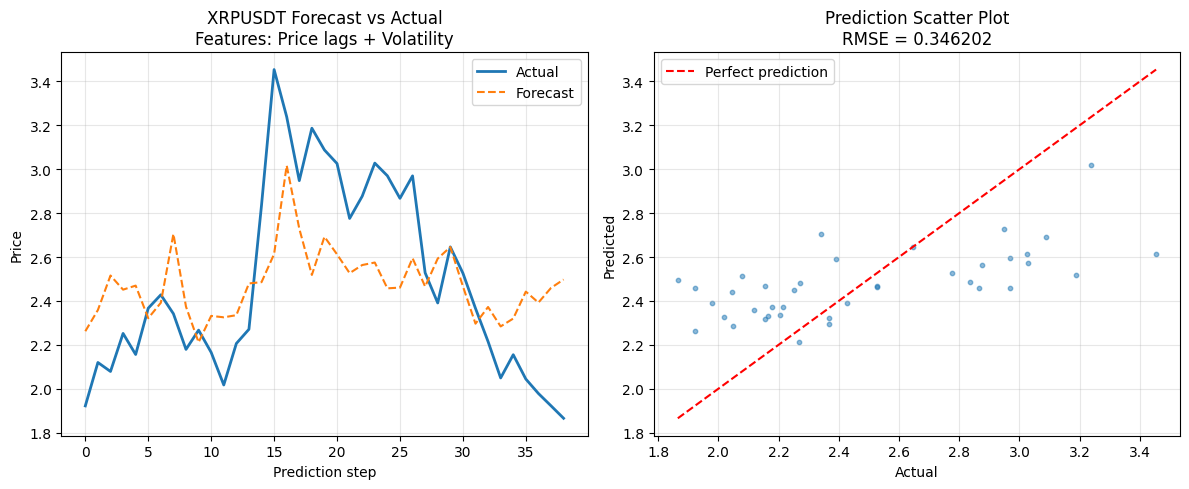


RMSE SUMMARY
                 RMSE  Mean_Actual_Price  NRMSE_Percent
ADAUSDT      0.083171           0.671769       0.123808
TRXUSDT      0.187022           0.296315       0.631159
XRPUSDT      0.346202           2.480085       0.139593
SOLUSDT     19.618005         167.505128       0.117119
BCHUSDT     63.932024         502.102564       0.127329
BNBUSDT    218.640986         820.774615       0.266384
ETHUSDT    557.175985        3219.931282       0.173040
BTCUSDT  13614.780602      104518.519744       0.130262

SUMMARY STATISTICS
Mean RMSE: 1809.345500
Median RMSE: 41.775014
Mean NRMSE (%): 0.2136%
Median NRMSE (%): 0.1349%
Best RMSE: 0.083171 (ADAUSDT)
Worst RMSE: 13614.780602 (BTCUSDT)


In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    # log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # volatility
    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    # lagged prices only
    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    # tiny coins
    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected â†’ using log price")
        df["close"] = np.log(df["close"])

    # add features: price lags + volatility only
    df = create_features(df)

    # target = future closing price HORIZON steps ahead
    df["target"] = df["close"].shift(-HORIZON)

    # drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # exclude target, keep everything else
    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    # Bayesian Optimisation
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 42
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (np.array(preds) - np.array(actual)) / np.array(actual)
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("12 XGB results/xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("12 XGB results/xgboost_rmse_summary_BO_price_vol.csv")


In [7]:
np.save("Results New/Features and BO new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/xgboost_rmse_summary_BO_price_vol.npy", rmse_table.values)
print("Saved .npy files for Model 3 (BO)")

Saved .npy files for Model 3 (BO)
